# Generate Graph

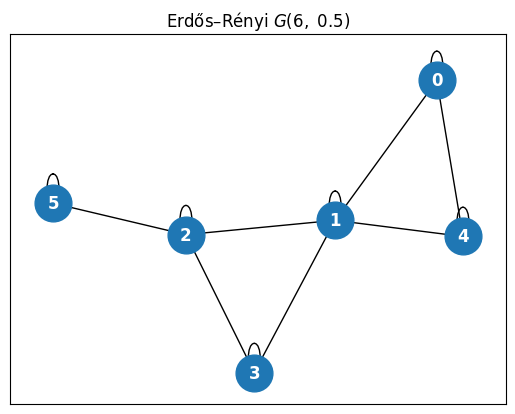

array([[1., 1., 0., 0., 1., 0.],
       [1., 1., 1., 1., 1., 0.],
       [0., 1., 1., 1., 0., 1.],
       [0., 1., 1., 1., 0., 0.],
       [1., 1., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 1.]])

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from graph import erdos_renyi_graph

m = 6
p = 0.5
seed = 42

A = erdos_renyi_graph(m, p, seed=seed)

G = nx.from_numpy_array(A, create_using=nx.Graph)
pos = nx.spring_layout(G, seed=seed)
nx.draw_networkx(G, pos=pos, node_color='tab:blue', node_size=700,
                  font_color='white', font_weight='bold')
plt.title(f'Erdős–Rényi $G({m},\\ {p})$')
plt.show()

A


# Optimize Physical MC (Kemeny)

Stationary distribution: pi_bar = [0.162  0.1961 0.1497 0.14   0.2067 0.1455]


/home/yohan/markov_chain_lifting/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Optimized Kemeny constant: K(P_bar*) = 9.0050
Conductance lower bound:   1/(2*Phi) = 1.5146


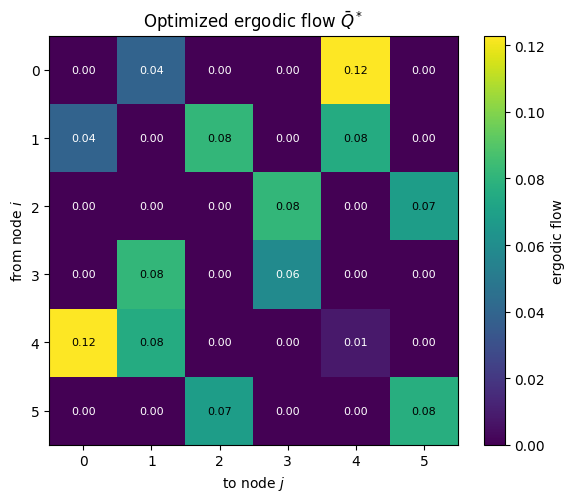

In [2]:
from markov import ergodic_flow_to_transition, conductance
from graph import random_chain
from optimize import _grad_kemeny, make_project_Q_bar, projected_gradient_descent

rng = np.random.default_rng(seed)

# Concentration parameter 5 keeps entries bounded away from zero (min entry ~
# 1/(2m) with high prob), which prevents near-singular gradient systems.
pi_bar = rng.dirichlet(5 * np.ones(m))
print(f"Stationary distribution: pi_bar = {np.round(pi_bar, 4)}")

n_init = 5
n_iter = 150
alpha = 2e-3
tol = 1e-5

phys_proj = make_project_Q_bar(A, pi_bar)

best_Q_bar = None
best_kemeny = np.inf
for _ in range(n_init):
    Q0 = random_chain(A, seed=int(rng.integers(1 << 31)))
    Q0 = phys_proj(Q0)
    Q_opt, hist, n_iters = projected_gradient_descent(
        Q0, _grad_kemeny, phys_proj, alpha, n_iter, tol,
    )
    if hist and hist[-1] < best_kemeny:
        best_kemeny = hist[-1]
        best_Q_bar = Q_opt

P_bar = ergodic_flow_to_transition(best_Q_bar)
_, conductance_lb = conductance(P_bar)

print(f"Optimized Kemeny constant: K(P_bar*) = {best_kemeny:.4f}")
print(f"Conductance lower bound:   1/(2*Phi) = {conductance_lb:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(best_Q_bar, cmap='viridis', vmin=0)
ax.set_xticks(range(m))
ax.set_yticks(range(m))
ax.set_xlabel('to node $j$')
ax.set_ylabel('from node $i$')
ax.set_title(r'Optimized ergodic flow $\bar Q^*$')
for i in range(m):
    for j in range(m):
        ax.text(j, i, f'{best_Q_bar[i, j]:.2f}', ha='center', va='center',
                color='white' if best_Q_bar[i, j] < 0.5 * best_Q_bar.max() else 'black', fontsize=8)
fig.colorbar(im, ax=ax, label='ergodic flow')
plt.tight_layout()
plt.show()


# Lifted MC Optimization Setup

In [ ]:
from graph import (
    uniform_lifting,
    stationary_lifting,
    degree_lifting,
    betweenness_lifting,
    eigenvector_lifting,
    reversible_flow_lifting,
)
from optimize import _grad_lifted_kemeny, make_project_Q

# Shared hyperparameters and quantities reused by every budget's lifted-MC
# optimization below, so they are computed once here.
n_init_lift = 5
n_iter_lift = 150
alpha_lift = 2e-3
tol_lift = 1e-5
eps = 1e-6

# sparsity pattern of the optimized physical MC, used to build each lifted graph
support = (best_Q_bar > eps).astype(int)


# Generate Liftings (budget = round(1.5m))

In [4]:
budget_15m = round(1.5 * m)

liftings_15m = {
    'uniform': uniform_lifting(A, budget_15m),
    'stationary': stationary_lifting(pi_bar, budget_15m),
    'degree': degree_lifting(A, budget_15m),
    'betweenness': betweenness_lifting(A, budget_15m),
    'eigenvector': eigenvector_lifting(A, budget_15m),
    'reversible_flow': reversible_flow_lifting(best_Q_bar, budget_15m),
}

for name, V in liftings_15m.items():
    print(f"{name:16s} n={V.shape[0]:2d}  counts={V.sum(axis=0).astype(int).tolist()}")


uniform          n= 9  counts=[2, 2, 2, 1, 1, 1]
stationary       n= 9  counts=[2, 2, 1, 1, 2, 1]
degree           n= 9  counts=[2, 2, 2, 1, 1, 1]
betweenness      n= 9  counts=[1, 3, 2, 1, 1, 1]
eigenvector      n= 9  counts=[1, 2, 2, 2, 1, 1]
reversible_flow  n= 9  counts=[2, 1, 1, 1, 2, 2]


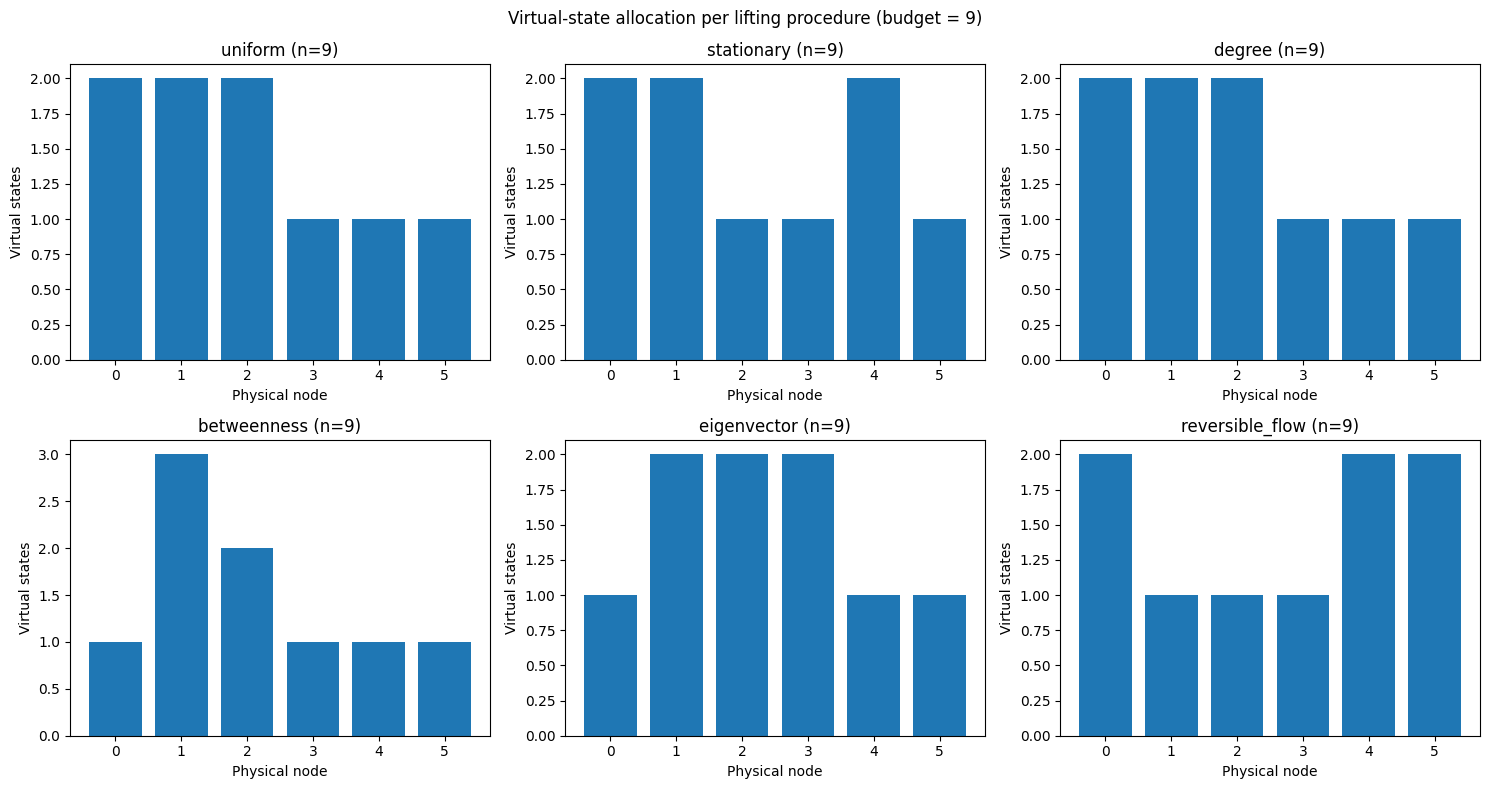

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for ax, (name, V) in zip(axes.flat, liftings_15m.items()):
    counts = V.sum(axis=0)
    ax.bar(range(m), counts, color='tab:blue')
    ax.set_title(f'{name} (n={V.shape[0]})')
    ax.set_xlabel('Physical node')
    ax.set_ylabel('Virtual states')
    ax.set_xticks(range(m))

fig.suptitle(f'Virtual-state allocation per lifting procedure (budget = {budget_15m})')
plt.tight_layout()
plt.show()


# Optimize Lifted MCs (budget = round(1.5m))

In [6]:
lifted_results_15m = {}
for name, V in liftings_15m.items():
    A_lift = V @ support @ V.T
    lift_proj = make_project_Q(best_Q_bar, V)

    best_Q_lift = None
    best_kemeny_lift = np.inf
    for _ in range(n_init_lift):
        Q0_lift = random_chain(A_lift, seed=int(rng.integers(1 << 31)))
        Q0_lift = lift_proj(Q0_lift)
        try:
            Q_lift_opt, hist_lift, n_iters_lift = projected_gradient_descent(
                Q0_lift,
                lambda Q, _V=V: _grad_lifted_kemeny(Q, _V, pi_bar),
                lift_proj,
                alpha_lift, n_iter_lift, tol_lift,
            )
        except (np.linalg.LinAlgError, RuntimeError) as e:
            print(f"  [{name}] lifted PGD init failed ({e}); skipping")
            continue
        if hist_lift and hist_lift[-1] < best_kemeny_lift:
            best_kemeny_lift = hist_lift[-1]
            best_Q_lift = Q_lift_opt

    lifted_results_15m[name] = (best_Q_lift, best_kemeny_lift)
    print(f"{name:16s} K^lift(P*) = {best_kemeny_lift:.4f}  "
          f"(physical K(P_bar*) = {best_kemeny:.4f}, diff = {best_kemeny - best_kemeny_lift:+.4f})")


uniform          K^lift(P*) = 5.4779  (physical K(P_bar*) = 9.0050, diff = +3.5272)
stationary       K^lift(P*) = 6.5517  (physical K(P_bar*) = 9.0050, diff = +2.4534)
degree           K^lift(P*) = 5.4778  (physical K(P_bar*) = 9.0050, diff = +3.5272)
betweenness      K^lift(P*) = 5.5793  (physical K(P_bar*) = 9.0050, diff = +3.4257)
eigenvector      K^lift(P*) = 5.6086  (physical K(P_bar*) = 9.0050, diff = +3.3965)
reversible_flow  K^lift(P*) = 8.3389  (physical K(P_bar*) = 9.0050, diff = +0.6662)


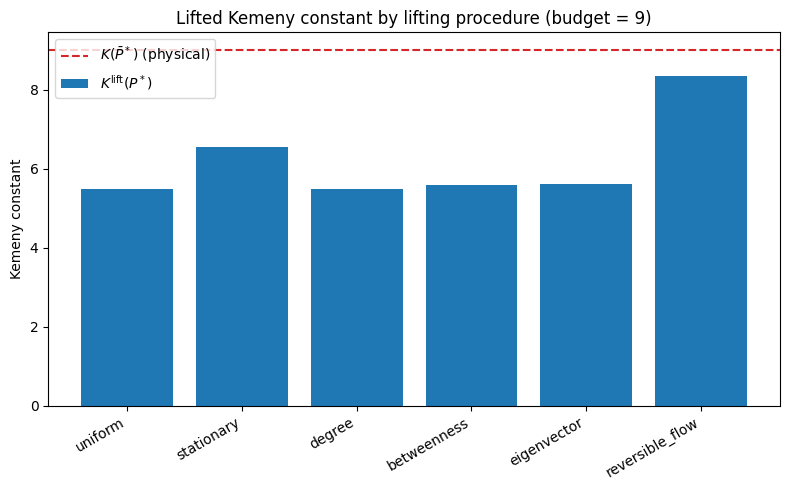

In [7]:
names_15m = list(lifted_results_15m.keys())
kemeny_lift_vals_15m = [lifted_results_15m[name][1] for name in names_15m]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(names_15m))
ax.bar(x, kemeny_lift_vals_15m, color='tab:blue', label=r'$K^{\mathrm{lift}}(P^*)$')
ax.axhline(best_kemeny, color='tab:red', linestyle='--', label=r'$K(\bar P^*)$ (physical)')
ax.set_xticks(x)
ax.set_xticklabels(names_15m, rotation=30, ha='right')
ax.set_ylabel('Kemeny constant')
ax.set_title(f'Lifted Kemeny constant by lifting procedure (budget = {budget_15m})')
ax.legend()
plt.tight_layout()
plt.show()


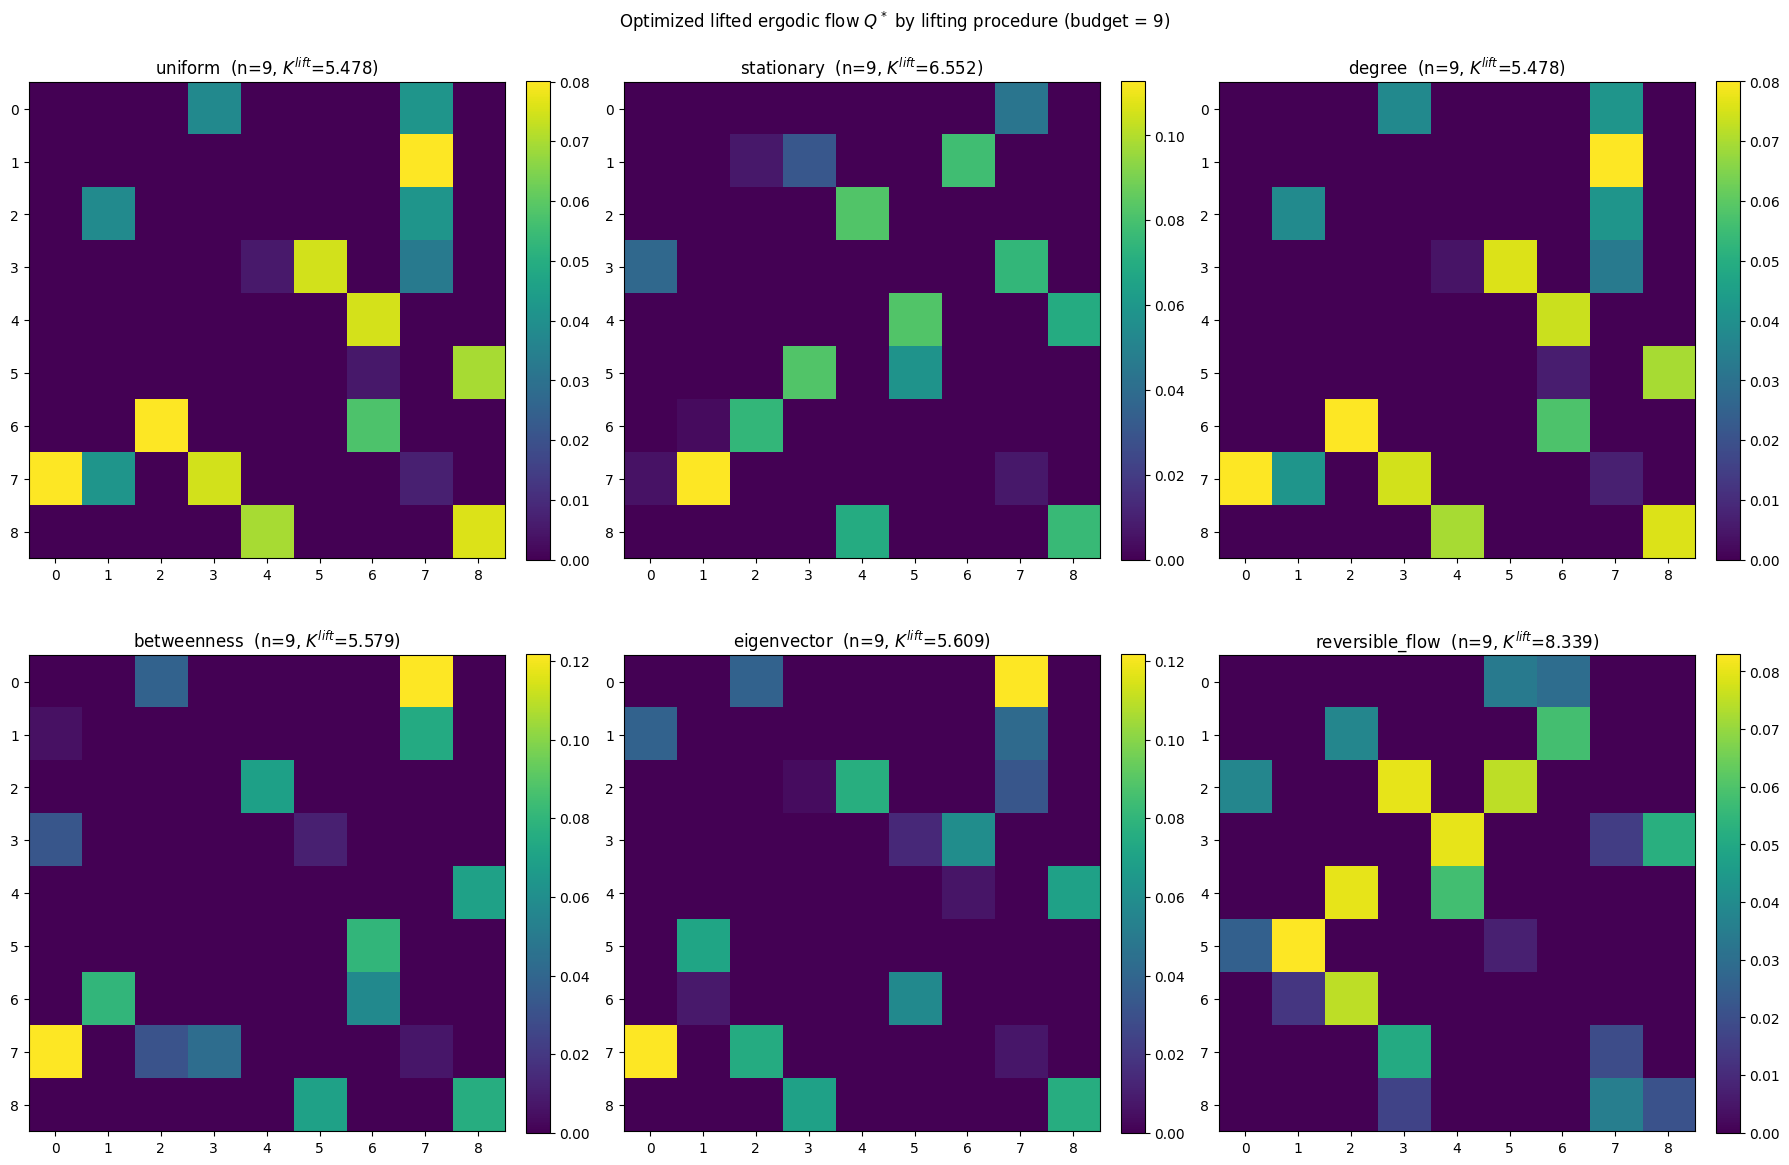

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (name, (Q_lift, k_lift)) in zip(axes.flat, lifted_results_15m.items()):
    n_lift = Q_lift.shape[0]
    im = ax.imshow(Q_lift, cmap='viridis', vmin=0)
    ax.set_title(f'{name}  (n={n_lift}, $K^{{lift}}$={k_lift:.3f})')
    ax.set_xticks(range(n_lift))
    ax.set_yticks(range(n_lift))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Optimized lifted ergodic flow $Q^*$ by lifting procedure (budget = {budget_15m})')
plt.tight_layout()
plt.show()


# Generate Liftings (budget = 2m)

In [9]:
budget_2m = 2 * m

liftings_2m = {
    'uniform': uniform_lifting(A, budget_2m),
    'stationary': stationary_lifting(pi_bar, budget_2m),
    'degree': degree_lifting(A, budget_2m),
    'betweenness': betweenness_lifting(A, budget_2m),
    'eigenvector': eigenvector_lifting(A, budget_2m),
    'reversible_flow': reversible_flow_lifting(best_Q_bar, budget_2m),
}

for name, V in liftings_2m.items():
    print(f"{name:16s} n={V.shape[0]:2d}  counts={V.sum(axis=0).astype(int).tolist()}")


uniform          n=12  counts=[2, 2, 2, 2, 2, 2]
stationary       n=12  counts=[2, 2, 2, 2, 2, 2]
degree           n=12  counts=[2, 3, 2, 2, 2, 1]
betweenness      n=12  counts=[1, 5, 3, 1, 1, 1]
eigenvector      n=12  counts=[2, 3, 2, 2, 2, 1]
reversible_flow  n=12  counts=[2, 2, 2, 1, 3, 2]


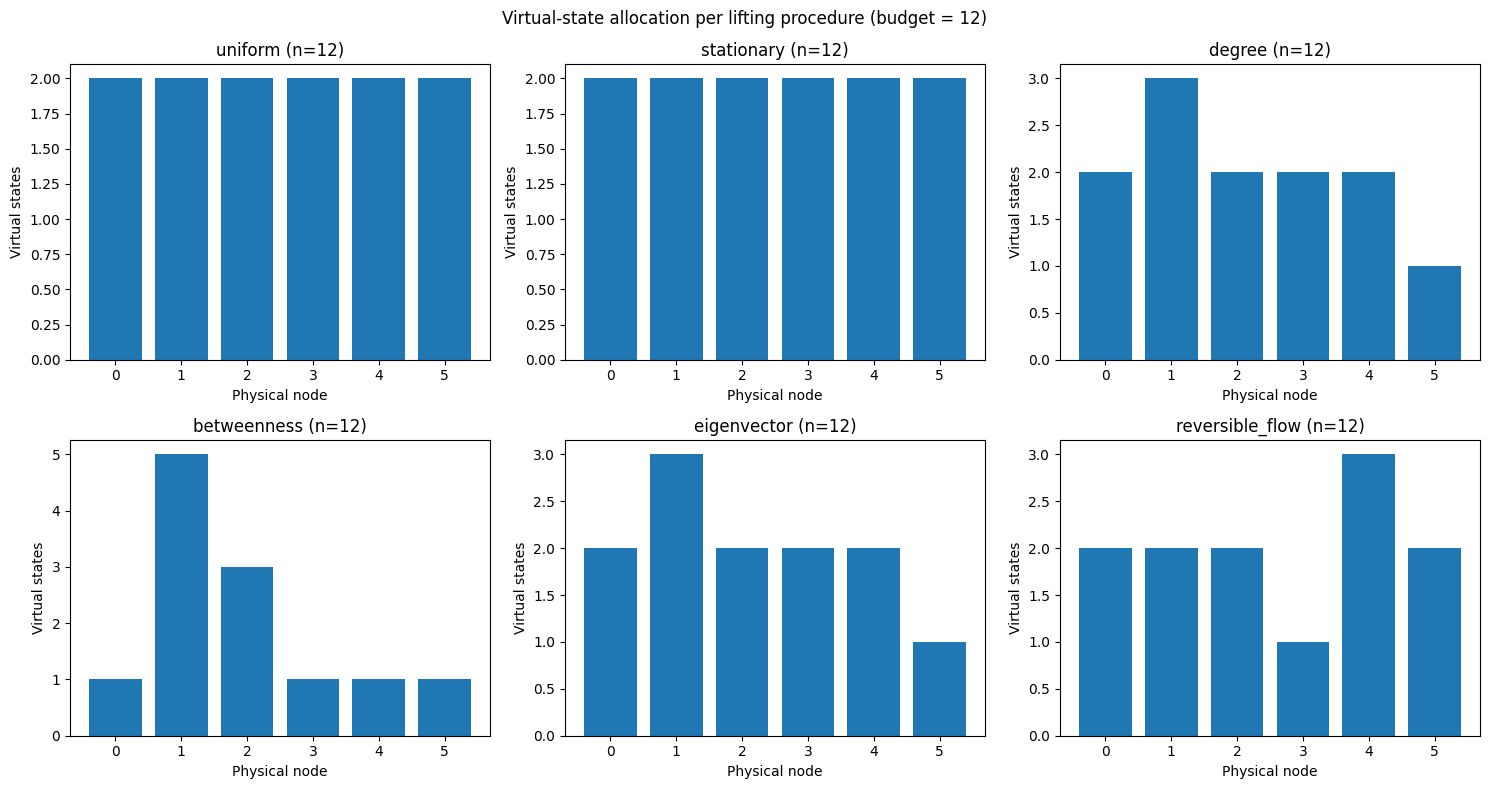

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for ax, (name, V) in zip(axes.flat, liftings_2m.items()):
    counts = V.sum(axis=0)
    ax.bar(range(m), counts, color='tab:blue')
    ax.set_title(f'{name} (n={V.shape[0]})')
    ax.set_xlabel('Physical node')
    ax.set_ylabel('Virtual states')
    ax.set_xticks(range(m))

fig.suptitle(f'Virtual-state allocation per lifting procedure (budget = {budget_2m})')
plt.tight_layout()
plt.show()


# Optimize Lifted MCs (budget = 2m)

In [11]:
lifted_results_2m = {}
for name, V in liftings_2m.items():
    A_lift = V @ support @ V.T
    lift_proj = make_project_Q(best_Q_bar, V)

    best_Q_lift = None
    best_kemeny_lift = np.inf
    for _ in range(n_init_lift):
        Q0_lift = random_chain(A_lift, seed=int(rng.integers(1 << 31)))
        Q0_lift = lift_proj(Q0_lift)
        try:
            Q_lift_opt, hist_lift, n_iters_lift = projected_gradient_descent(
                Q0_lift,
                lambda Q, _V=V: _grad_lifted_kemeny(Q, _V, pi_bar),
                lift_proj,
                alpha_lift, n_iter_lift, tol_lift,
            )
        except (np.linalg.LinAlgError, RuntimeError) as e:
            print(f"  [{name}] lifted PGD init failed ({e}); skipping")
            continue
        if hist_lift and hist_lift[-1] < best_kemeny_lift:
            best_kemeny_lift = hist_lift[-1]
            best_Q_lift = Q_lift_opt

    lifted_results_2m[name] = (best_Q_lift, best_kemeny_lift)
    print(f"{name:16s} K^lift(P*) = {best_kemeny_lift:.4f}  "
          f"(physical K(P_bar*) = {best_kemeny:.4f}, diff = {best_kemeny - best_kemeny_lift:+.4f})")


/home/yohan/markov_chain_lifting/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


uniform          K^lift(P*) = 4.9828  (physical K(P_bar*) = 9.0050, diff = +4.0223)
stationary       K^lift(P*) = 4.9893  (physical K(P_bar*) = 9.0050, diff = +4.0157)
degree           K^lift(P*) = 4.9798  (physical K(P_bar*) = 9.0050, diff = +4.0252)
betweenness      K^lift(P*) = 5.5798  (physical K(P_bar*) = 9.0050, diff = +3.4252)
eigenvector      K^lift(P*) = 4.9798  (physical K(P_bar*) = 9.0050, diff = +4.0253)
reversible_flow  K^lift(P*) = 4.9660  (physical K(P_bar*) = 9.0050, diff = +4.0390)


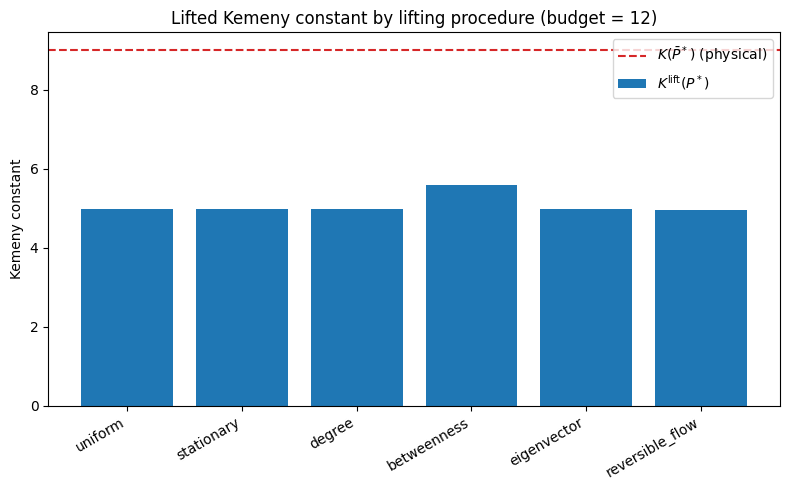

In [12]:
names_2m = list(lifted_results_2m.keys())
kemeny_lift_vals_2m = [lifted_results_2m[name][1] for name in names_2m]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(names_2m))
ax.bar(x, kemeny_lift_vals_2m, color='tab:blue', label=r'$K^{\mathrm{lift}}(P^*)$')
ax.axhline(best_kemeny, color='tab:red', linestyle='--', label=r'$K(\bar P^*)$ (physical)')
ax.set_xticks(x)
ax.set_xticklabels(names_2m, rotation=30, ha='right')
ax.set_ylabel('Kemeny constant')
ax.set_title(f'Lifted Kemeny constant by lifting procedure (budget = {budget_2m})')
ax.legend()
plt.tight_layout()
plt.show()


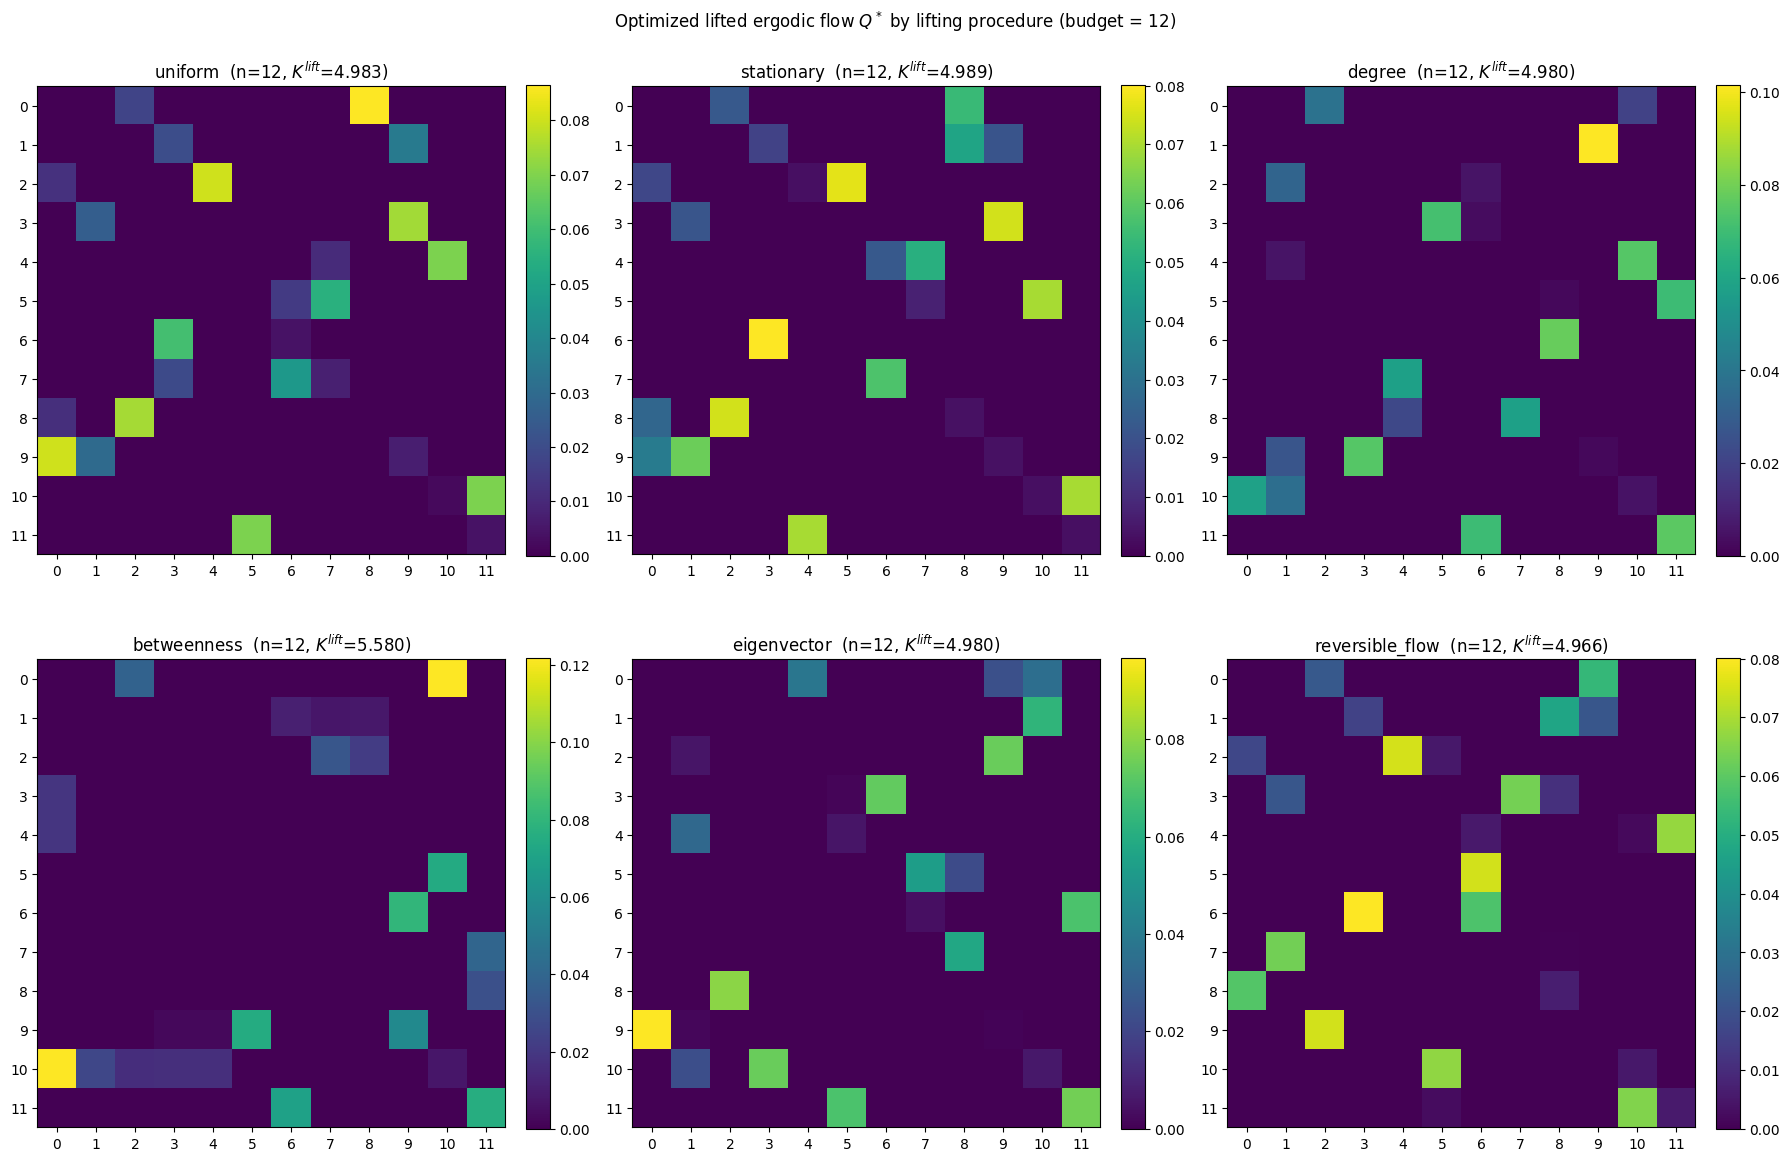

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (name, (Q_lift, k_lift)) in zip(axes.flat, lifted_results_2m.items()):
    n_lift = Q_lift.shape[0]
    im = ax.imshow(Q_lift, cmap='viridis', vmin=0)
    ax.set_title(f'{name}  (n={n_lift}, $K^{{lift}}$={k_lift:.3f})')
    ax.set_xticks(range(n_lift))
    ax.set_yticks(range(n_lift))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Optimized lifted ergodic flow $Q^*$ by lifting procedure (budget = {budget_2m})')
plt.tight_layout()
plt.show()


# Generate Liftings (budget = 3m)

In [14]:
budget_3m = 3 * m

liftings_3m = {
    'uniform': uniform_lifting(A, budget_3m),
    'stationary': stationary_lifting(pi_bar, budget_3m),
    'degree': degree_lifting(A, budget_3m),
    'betweenness': betweenness_lifting(A, budget_3m),
    'eigenvector': eigenvector_lifting(A, budget_3m),
    'reversible_flow': reversible_flow_lifting(best_Q_bar, budget_3m),
}

for name, V in liftings_3m.items():
    print(f"{name:16s} n={V.shape[0]:2d}  counts={V.sum(axis=0).astype(int).tolist()}")


uniform          n=18  counts=[3, 3, 3, 3, 3, 3]
stationary       n=18  counts=[3, 3, 3, 3, 3, 3]
degree           n=18  counts=[3, 4, 3, 3, 3, 2]
betweenness      n=18  counts=[1, 8, 6, 1, 1, 1]
eigenvector      n=18  counts=[3, 4, 3, 3, 3, 2]
reversible_flow  n=18  counts=[4, 3, 2, 2, 4, 3]


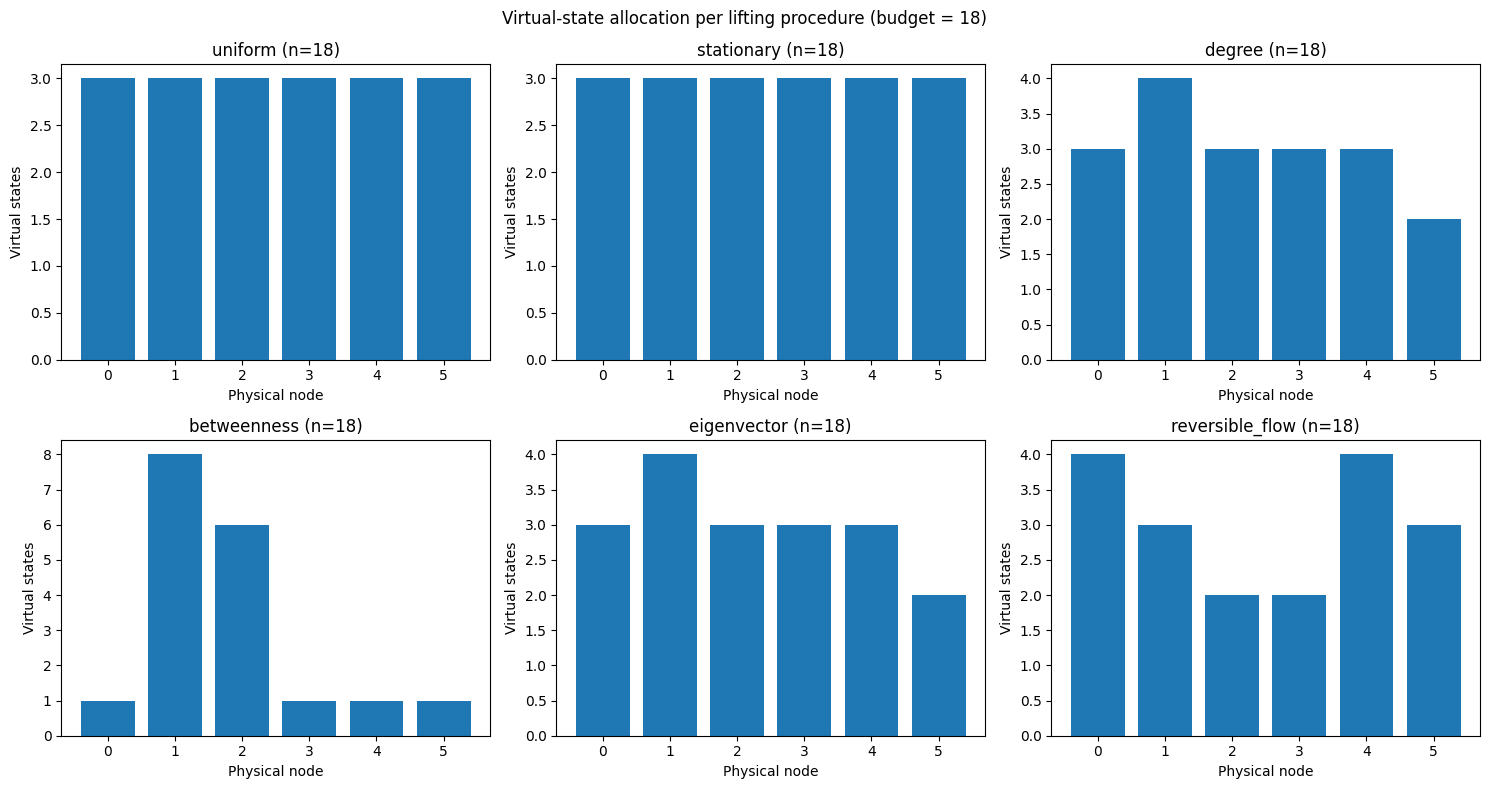

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for ax, (name, V) in zip(axes.flat, liftings_3m.items()):
    counts = V.sum(axis=0)
    ax.bar(range(m), counts, color='tab:blue')
    ax.set_title(f'{name} (n={V.shape[0]})')
    ax.set_xlabel('Physical node')
    ax.set_ylabel('Virtual states')
    ax.set_xticks(range(m))

fig.suptitle(f'Virtual-state allocation per lifting procedure (budget = {budget_3m})')
plt.tight_layout()
plt.show()


# Optimize Lifted MCs (budget = 3m)

In [16]:
lifted_results_3m = {}
for name, V in liftings_3m.items():
    A_lift = V @ support @ V.T
    lift_proj = make_project_Q(best_Q_bar, V)

    best_Q_lift = None
    best_kemeny_lift = np.inf
    for _ in range(n_init_lift):
        Q0_lift = random_chain(A_lift, seed=int(rng.integers(1 << 31)))
        Q0_lift = lift_proj(Q0_lift)
        try:
            Q_lift_opt, hist_lift, n_iters_lift = projected_gradient_descent(
                Q0_lift,
                lambda Q, _V=V: _grad_lifted_kemeny(Q, _V, pi_bar),
                lift_proj,
                alpha_lift, n_iter_lift, tol_lift,
            )
        except (np.linalg.LinAlgError, RuntimeError) as e:
            print(f"  [{name}] lifted PGD init failed ({e}); skipping")
            continue
        if hist_lift and hist_lift[-1] < best_kemeny_lift:
            best_kemeny_lift = hist_lift[-1]
            best_Q_lift = Q_lift_opt

    lifted_results_3m[name] = (best_Q_lift, best_kemeny_lift)
    print(f"{name:16s} K^lift(P*) = {best_kemeny_lift:.4f}  "
          f"(physical K(P_bar*) = {best_kemeny:.4f}, diff = {best_kemeny - best_kemeny_lift:+.4f})")


/home/yohan/markov_chain_lifting/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


uniform          K^lift(P*) = 4.8561  (physical K(P_bar*) = 9.0050, diff = +4.1489)
stationary       K^lift(P*) = 4.8409  (physical K(P_bar*) = 9.0050, diff = +4.1641)
degree           K^lift(P*) = 4.8258  (physical K(P_bar*) = 9.0050, diff = +4.1793)
ERROR in osqp_update_data_vec: Problem data validation.
ERROR in osqp_update_data_vec: Problem data validation.
ERROR in osqp_update_data_vec: Problem data validation.
ERROR in osqp_update_data_vec: Problem data validation.
ERROR in osqp_update_data_vec: Problem data validation.
ERROR in osqp_update_data_vec: Problem data validation.
ERROR in osqp_update_data_vec: Problem data validation.
betweenness      K^lift(P*) = 5.5812  (physical K(P_bar*) = 9.0050, diff = +3.4239)
eigenvector      K^lift(P*) = 4.8359  (physical K(P_bar*) = 9.0050, diff = +4.1691)
  [reversible_flow] lifted PGD init failed (Singular matrix); skipping
reversible_flow  K^lift(P*) = 4.8884  (physical K(P_bar*) = 9.0050, diff = +4.1166)


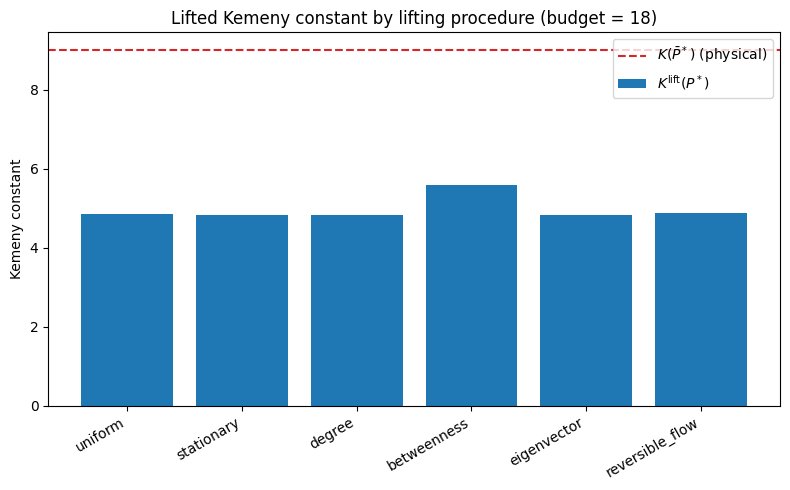

In [17]:
names_3m = list(lifted_results_3m.keys())
kemeny_lift_vals_3m = [lifted_results_3m[name][1] for name in names_3m]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(names_3m))
ax.bar(x, kemeny_lift_vals_3m, color='tab:blue', label=r'$K^{\mathrm{lift}}(P^*)$')
ax.axhline(best_kemeny, color='tab:red', linestyle='--', label=r'$K(\bar P^*)$ (physical)')
ax.set_xticks(x)
ax.set_xticklabels(names_3m, rotation=30, ha='right')
ax.set_ylabel('Kemeny constant')
ax.set_title(f'Lifted Kemeny constant by lifting procedure (budget = {budget_3m})')
ax.legend()
plt.tight_layout()
plt.show()


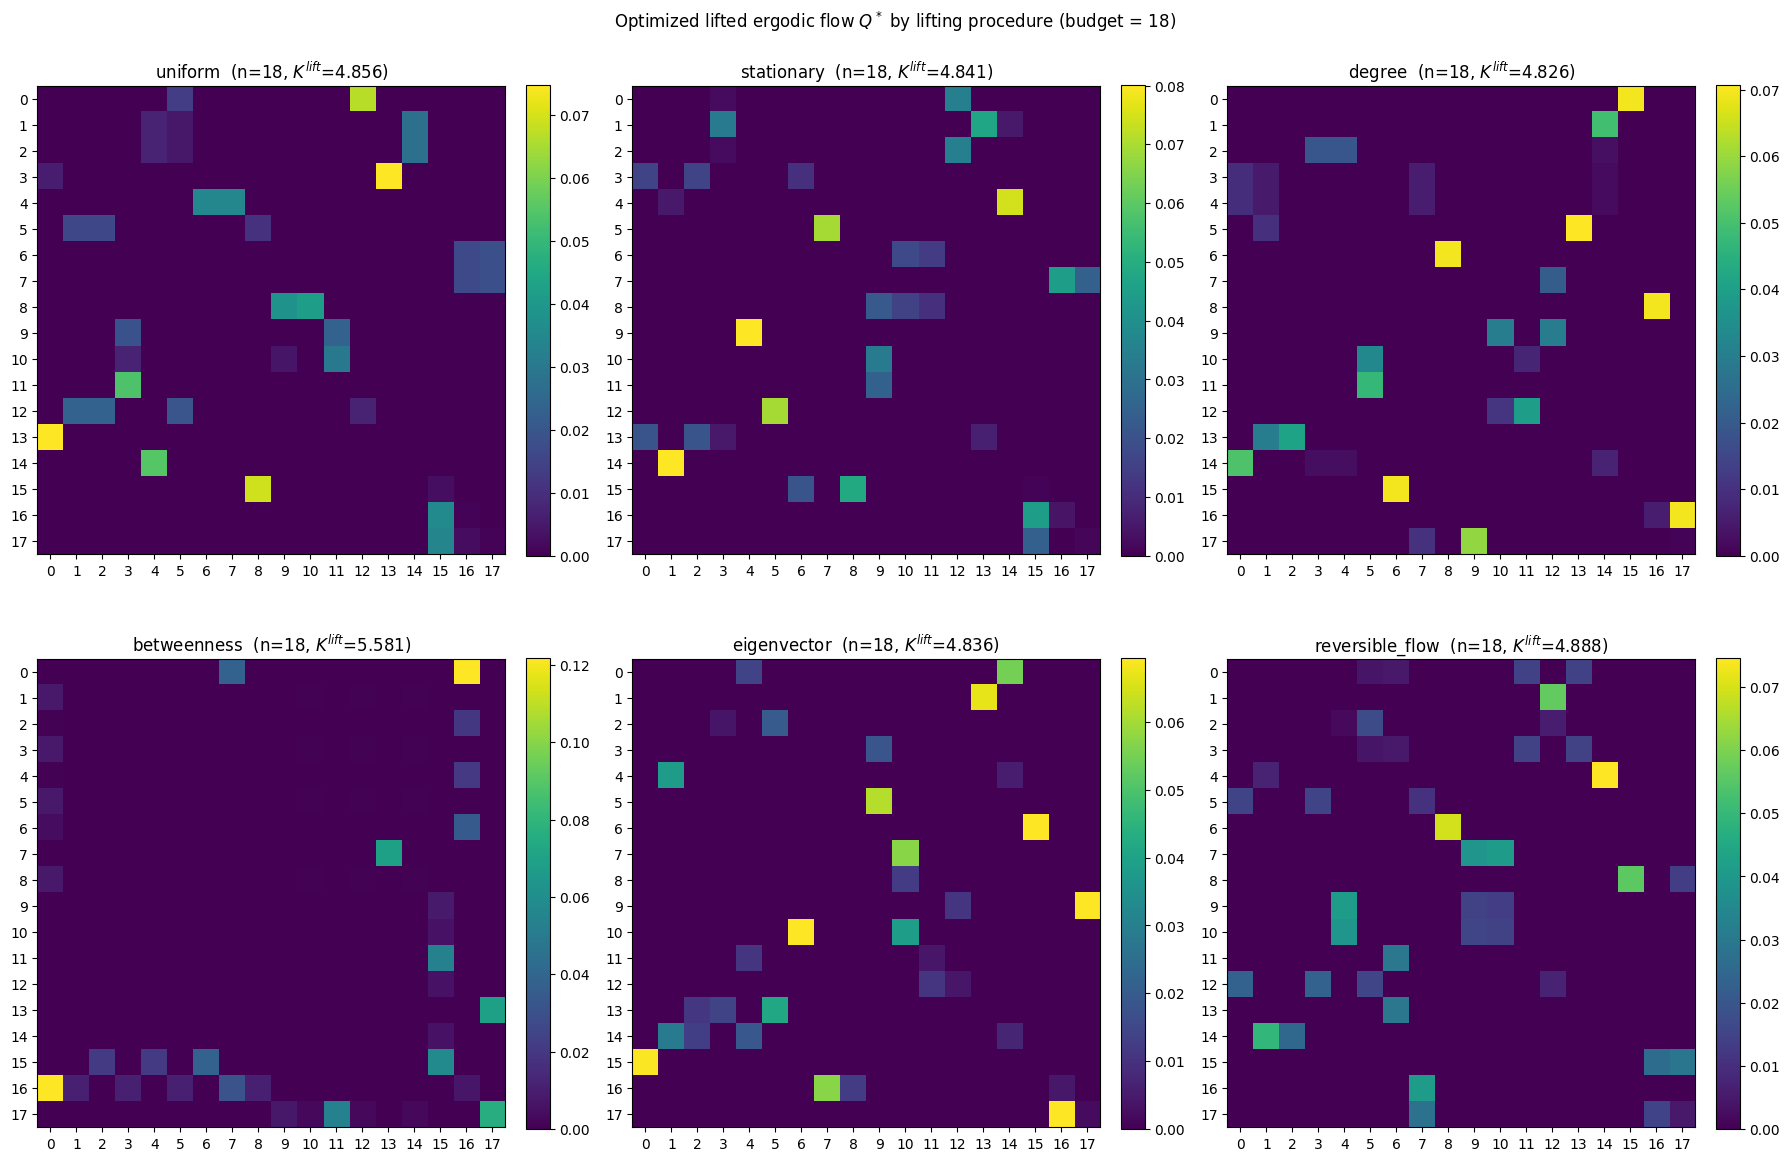

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (name, (Q_lift, k_lift)) in zip(axes.flat, lifted_results_3m.items()):
    n_lift = Q_lift.shape[0]
    im = ax.imshow(Q_lift, cmap='viridis', vmin=0)
    ax.set_title(f'{name}  (n={n_lift}, $K^{{lift}}$={k_lift:.3f})')
    ax.set_xticks(range(n_lift))
    ax.set_yticks(range(n_lift))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Optimized lifted ergodic flow $Q^*$ by lifting procedure (budget = {budget_3m})')
plt.tight_layout()
plt.show()
